# Bloque 1: Análisis Exploratorio 
# Sartorius Cell Instance Segmentation

Este notebook presenta el análisis exploratorio y el pipeline de preprocesamiento implementado sobre el dataset Sartorius Cell Instance Segmentation para tareas de segmentación celular mediante Deep Learning.

Los objetivos principales son:

- comprender la estructura del dataset,
- analizar la distribución celular,
- estudiar variabilidad morfológica,
- identificar posibles desbalances,
- construir máscaras a partir de anotaciones RLE,
- y preparar las imágenes para entrenamiento profundo.

El dataset Sartorius Cell Instance Segmentation contiene imágenes microscópicas anotadas para tareas de segmentación celular.

Cada muestra incluye:

- identificador de imagen,
- dimensiones espaciales,
- tipo celular,
- anotaciones RLE (Run Length Encoding).

In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ── Ruta del dataset ──────────────────────────────────────────────
DATA_DIR = r"C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\mini3\Bloque1\data\sartorius-cell-instance-segmentation"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
CSV_PATH  = os.path.join(DATA_DIR, "train.csv")

# ── Verificación ──────────────────────────────────────────────────
print("¿Existe train/?", os.path.exists(TRAIN_DIR))
print("¿Existe train.csv?", os.path.exists(CSV_PATH))

imagenes = os.listdir(TRAIN_DIR)
print(f"Total imágenes en train/: {len(imagenes)}")
print("Primeras 5:", imagenes[:5])

¿Existe train/? True
¿Existe train.csv? True
Total imágenes en train/: 606
Primeras 5: ['0030fd0e6378.png', '0140b3c8f445.png', '01ae5a43a2ab.png', '026b3c2c4b32.png', '029e5b3b89c7.png']


In [4]:
# ── Carga del CSV de anotaciones ──────────────────────────────────
df_raw = pd.read_csv(CSV_PATH)
print("Shape del CSV:", df_raw.shape)
print("\nColumnas:", df_raw.columns.tolist())
print("\nPrimeras filas:")
df_raw.head(10)

Shape del CSV: (73585, 9)

Columnas: ['id', 'annotation', 'width', 'height', 'cell_type', 'plate_time', 'sample_date', 'sample_id', 'elapsed_timedelta']

Primeras filas:


,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
5,0030fd0e6378,205984 2 206687 4 207391 5 208095 5 208799 6 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
6,0030fd0e6378,203101 2 203805 5 204509 7 205213 10 205917 12...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
7,0030fd0e6378,191900 2 192604 3 193308 4 194012 5 194717 5 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
8,0030fd0e6378,184848 3 185551 5 186254 7 186958 8 187662 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
9,0030fd0e6378,165119 1 165822 4 166526 6 167230 9 167935 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


In [5]:
# ── Exploración inicial del CSV ───────────────────────────────────
print("Tipos de célula únicos:", df_raw['cell_type'].unique())
print("\nDistribución por tipo de célula:")
print(df_raw.groupby('cell_type')['id'].nunique().rename('n_imagenes'))

print("\n¿Hay nulos en annotation?:", df_raw['annotation'].isnull().sum())
print("\nEjemplo de RLE:")
print(df_raw['annotation'].iloc[0][:80], "...")

Tipos de célula únicos: ['shsy5y' 'astro' 'cort']

Distribución por tipo de célula:
cell_type
astro     131
cort      320
shsy5y    155
Name: n_imagenes, dtype: int64

¿Hay nulos en annotation?: 0

Ejemplo de RLE:
118145 6 118849 7 119553 8 120257 8 120961 9 121665 10 122369 12 123074 13 12377 ...


In [6]:
import cv2
from pathlib import Path

# ajusta esto a tu ruta real del dataset
DATASET_PATH = Path("../data/sartorius-cell-instance-segmentation/train")

def load_image(image_id):

    image_path = DATASET_PATH / f"{image_id}.png"

    img = cv2.imread(str(image_path))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

Filas únicas: [167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
 185 186 187 188 189 190 191 192 193 194 195 196]
Cols únicas: [576 577 578 579 580 581 582 583 584 585 586 587 588 589 590 591 592 593
 594 595 596 597 598 599 600 601 602]
Píxeles activos: 498


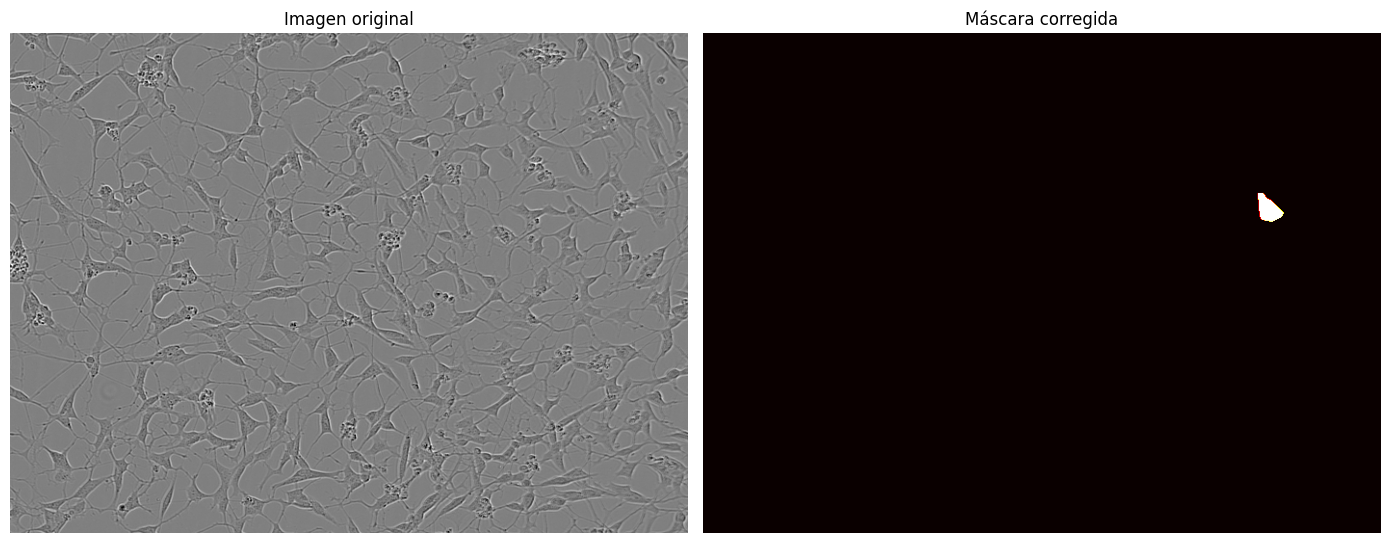

In [7]:
def rle_decode(rle_string, height, width):
    if pd.isna(rle_string):
        return np.zeros((height, width), dtype=np.uint8)
    
    nums = list(map(int, rle_string.split()))
    starts = nums[0::2]
    lengths = nums[1::2]
    
    mask = np.zeros((height, width), dtype=np.uint8)
    for start, length in zip(starts, lengths):
        start -= 1
        for i in range(length):
            pixel = start + i
            row = pixel // width     # ← invertido
            col = pixel % width      # ← invertido
            if row < height and col < width:
                mask[row, col] = 1
    return mask

# ── Verificar ────────────────────────────────────────────────────
fila = df_raw.iloc[0]
mascara = rle_decode(fila['annotation'], fila['height'], fila['width'])

rows_activos, cols_activos = np.where(mascara == 1)
print("Filas únicas:", np.unique(rows_activos))
print("Cols únicas:", np.unique(cols_activos))
print("Píxeles activos:", mascara.sum())

img = load_image(fila['id'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].set_title('Imagen original')
axes[0].axis('off')
axes[1].imshow(mascara, cmap='hot')
axes[1].set_title('Máscara corregida')
axes[1].axis('off')
plt.tight_layout()
plt.show()

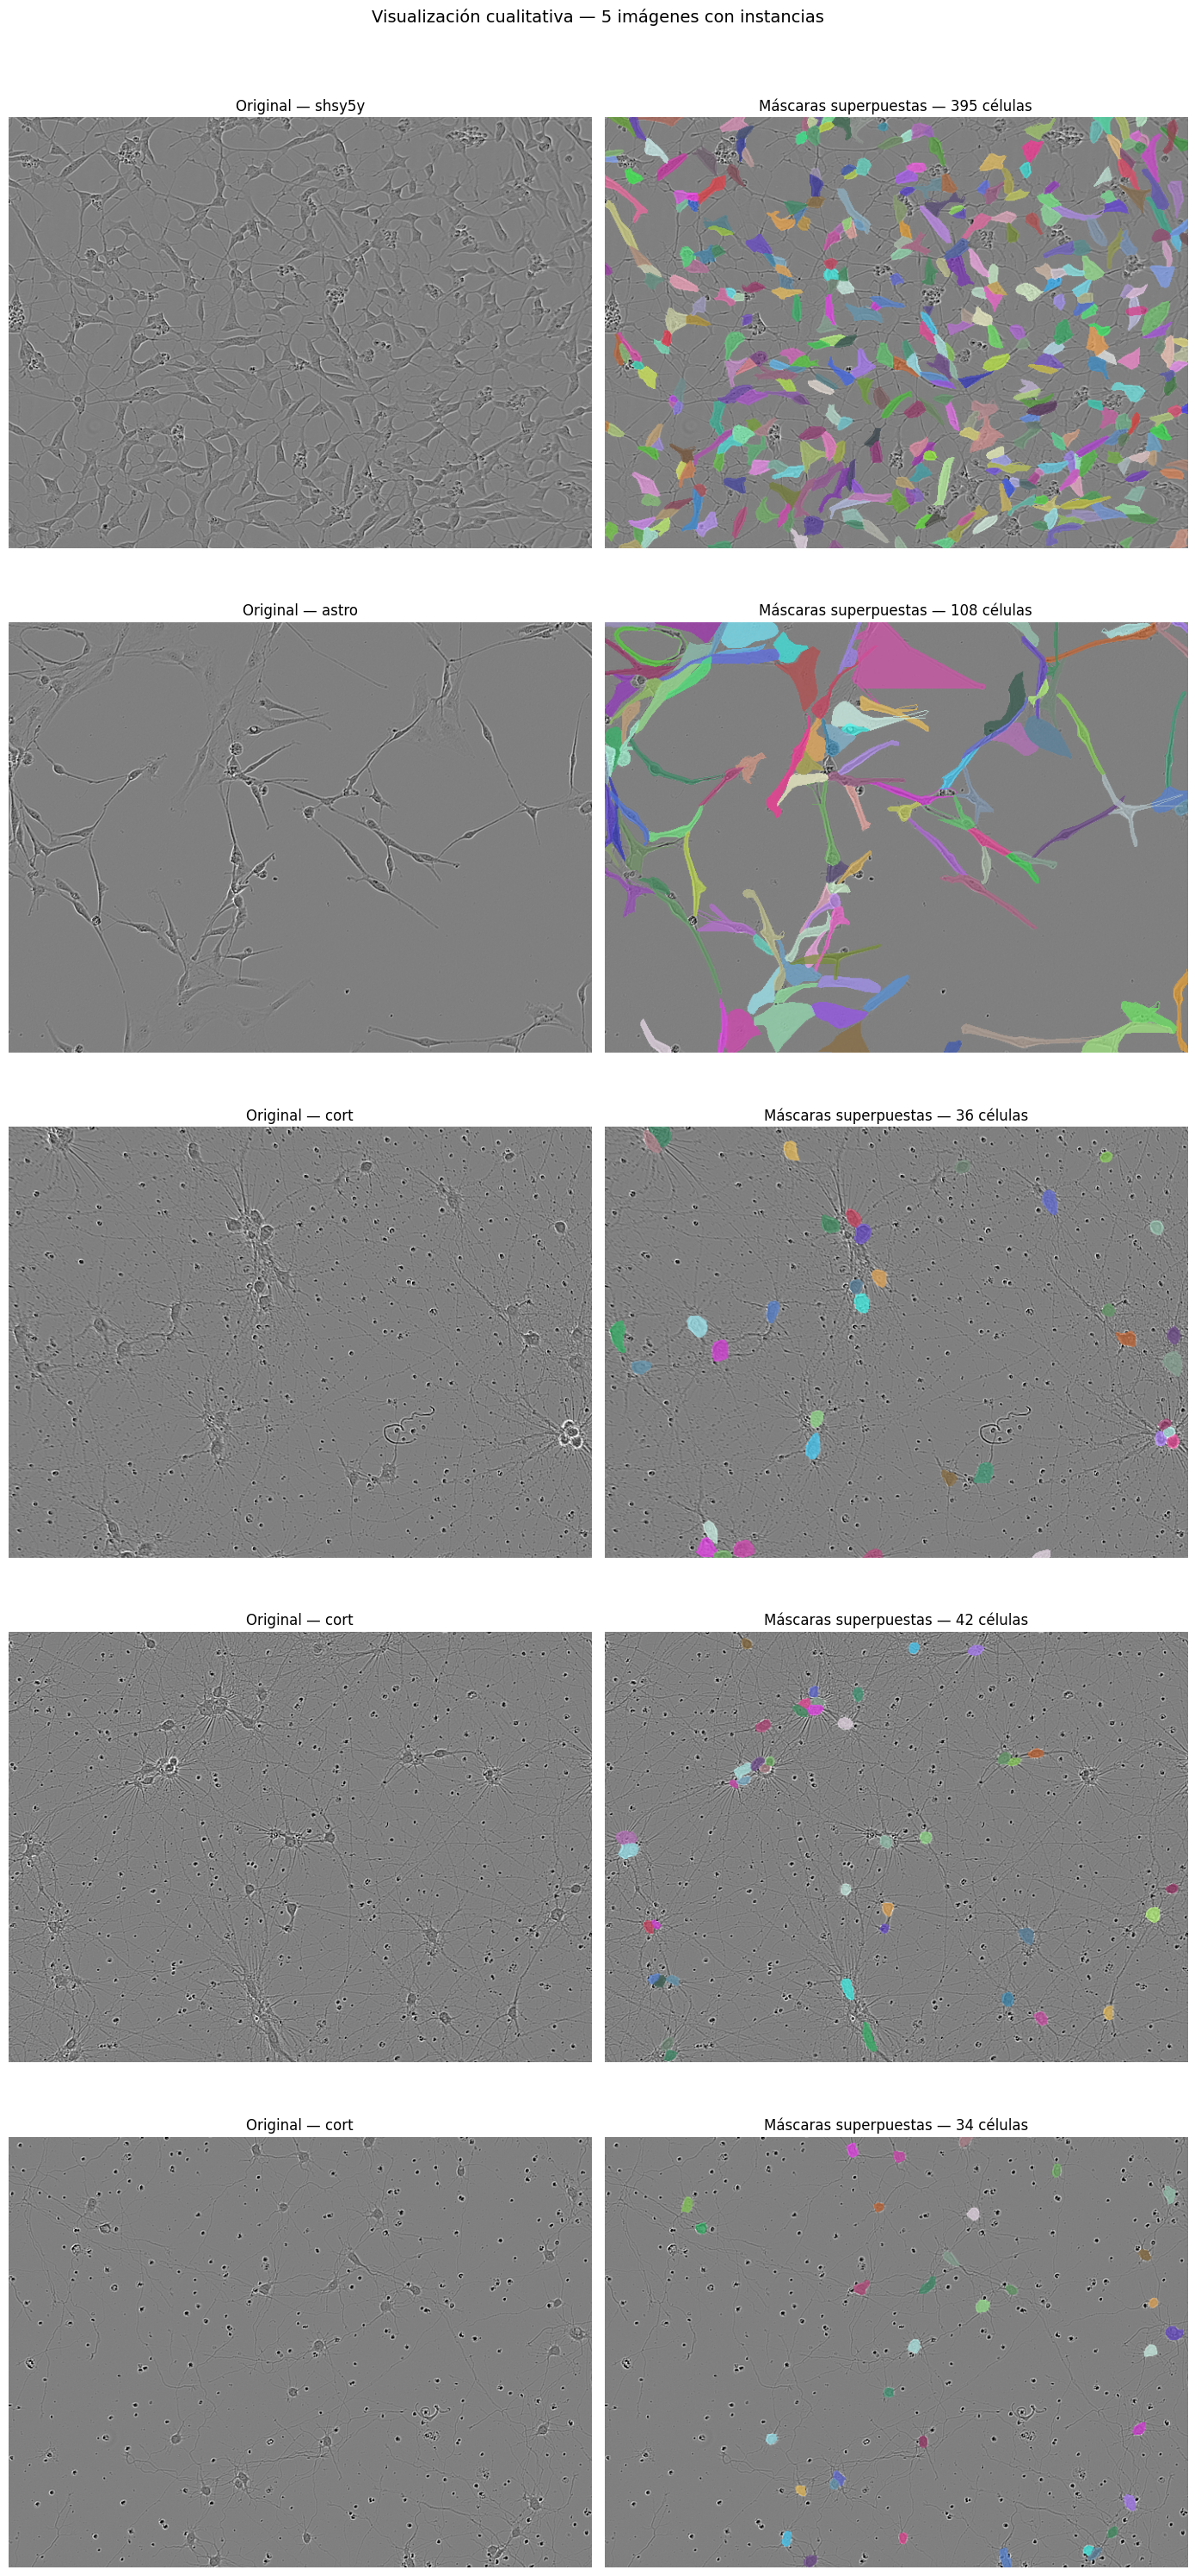

In [8]:
# ── Overlay completo con la función corregida ─────────────────────
def get_all_masks(img_id, df):
    rows = df[df['id'] == img_id]
    h, w = rows.iloc[0]['height'], rows.iloc[0]['width']
    masks = []
    for _, row in rows.iterrows():
        mask = rle_decode(row['annotation'], h, w)
        masks.append(mask)
    return masks, h, w

def overlay_masks(img, masks):
    overlay = img.copy().astype(np.float32)
    np.random.seed(42)
    for mask in masks:
        color = np.random.randint(50, 255, size=3).astype(np.float32)
        overlay[mask == 1] = overlay[mask == 1] * 0.3 + color * 0.7
    return np.clip(overlay, 0, 255).astype(np.uint8)

# ── Visualizar las 5 imágenes obligatorias del EDA ───────────────
img_ids = df_raw['id'].unique()[:5]

fig, axes = plt.subplots(5, 2, figsize=(14, 30))

for i, img_id in enumerate(img_ids):
    masks, h, w = get_all_masks(img_id, df_raw)
    img = load_image(img_id)
    overlay = overlay_masks(img, masks)
    
    cell_type = df_raw[df_raw['id'] == img_id]['cell_type'].iloc[0]
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original — {cell_type}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f'Máscaras superpuestas — {len(masks)} células')
    axes[i, 1].axis('off')

plt.suptitle('Visualización cualitativa — 5 imágenes con instancias', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# ── Celda 5: Dataframe estructurado obligatorio ───────────────────
print("Construyendo dataframe estructurado")

records = []
for img_id, group in df_raw.groupby('id'):
    h = group.iloc[0]['height']
    w = group.iloc[0]['width']
    cell_type = group.iloc[0]['cell_type']
    n_masks = len(group)
    
    areas = []
    for _, row in group.iterrows():
        nums = list(map(int, row['annotation'].split()))
        area = sum(nums[1::2])  # suma de lengths del RLE = área en píxeles
        areas.append(area)
    
    records.append({
        'id_imagen'   : img_id,
        'ruta_imagen' : f"{TRAIN_DIR}\\{img_id}.png",
        'cell_type'   : cell_type,
        'height'      : h,
        'width'       : w,
        'n_celulas'   : n_masks,
        'area_total'  : sum(areas),
        'area_media'  : np.mean(areas),
        'area_min'    : min(areas),
        'area_max'    : max(areas),
    })

df_images = pd.DataFrame(records)
print(f"Dataframe listo: {df_images.shape}")
print(f"\nDistribución por tipo de célula:")
print(df_images.groupby('cell_type')['n_celulas'].describe().round(1))
df_images.head()

Construyendo dataframe estructurado
Dataframe listo: (606, 10)

Distribución por tipo de célula:
           count   mean    std   min    25%    50%    75%    max
cell_type                                                       
astro      131.0   80.3   64.1   5.0   50.0   73.0  100.0  594.0
cort       320.0   33.7   16.5   4.0   23.0   30.0   39.0  108.0
shsy5y     155.0  337.3  149.6  49.0  235.5  324.0  429.0  790.0


,id_imagen,ruta_imagen,cell_type,height,width,n_celulas,area_total,area_media,area_min,area_max
0,0030fd0e6378,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,shsy5y,520,704,395,113307,286.853165,46,757
1,0140b3c8f445,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,astro,520,704,108,86735,803.101852,138,7126
2,01ae5a43a2ab,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,cort,520,704,36,11382,316.166667,149,522
3,026b3c2c4b32,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,cort,520,704,42,7660,182.380952,84,355
4,029e5b3b89c7,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,cort,520,704,34,5753,169.205882,107,277


C:\Users\maria\AppData\Local\Temp\ipykernel_33808\620900735.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(data_box, labels=['shsy5y', 'astro', 'cort'], patch_artist=True)
C:\Users\maria\AppData\Local\Temp\ipykernel_33808\620900735.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax7.boxplot(data_area, labels=['shsy5y', 'astro', 'cort'], patch_artist=True)


Calculando intensidades


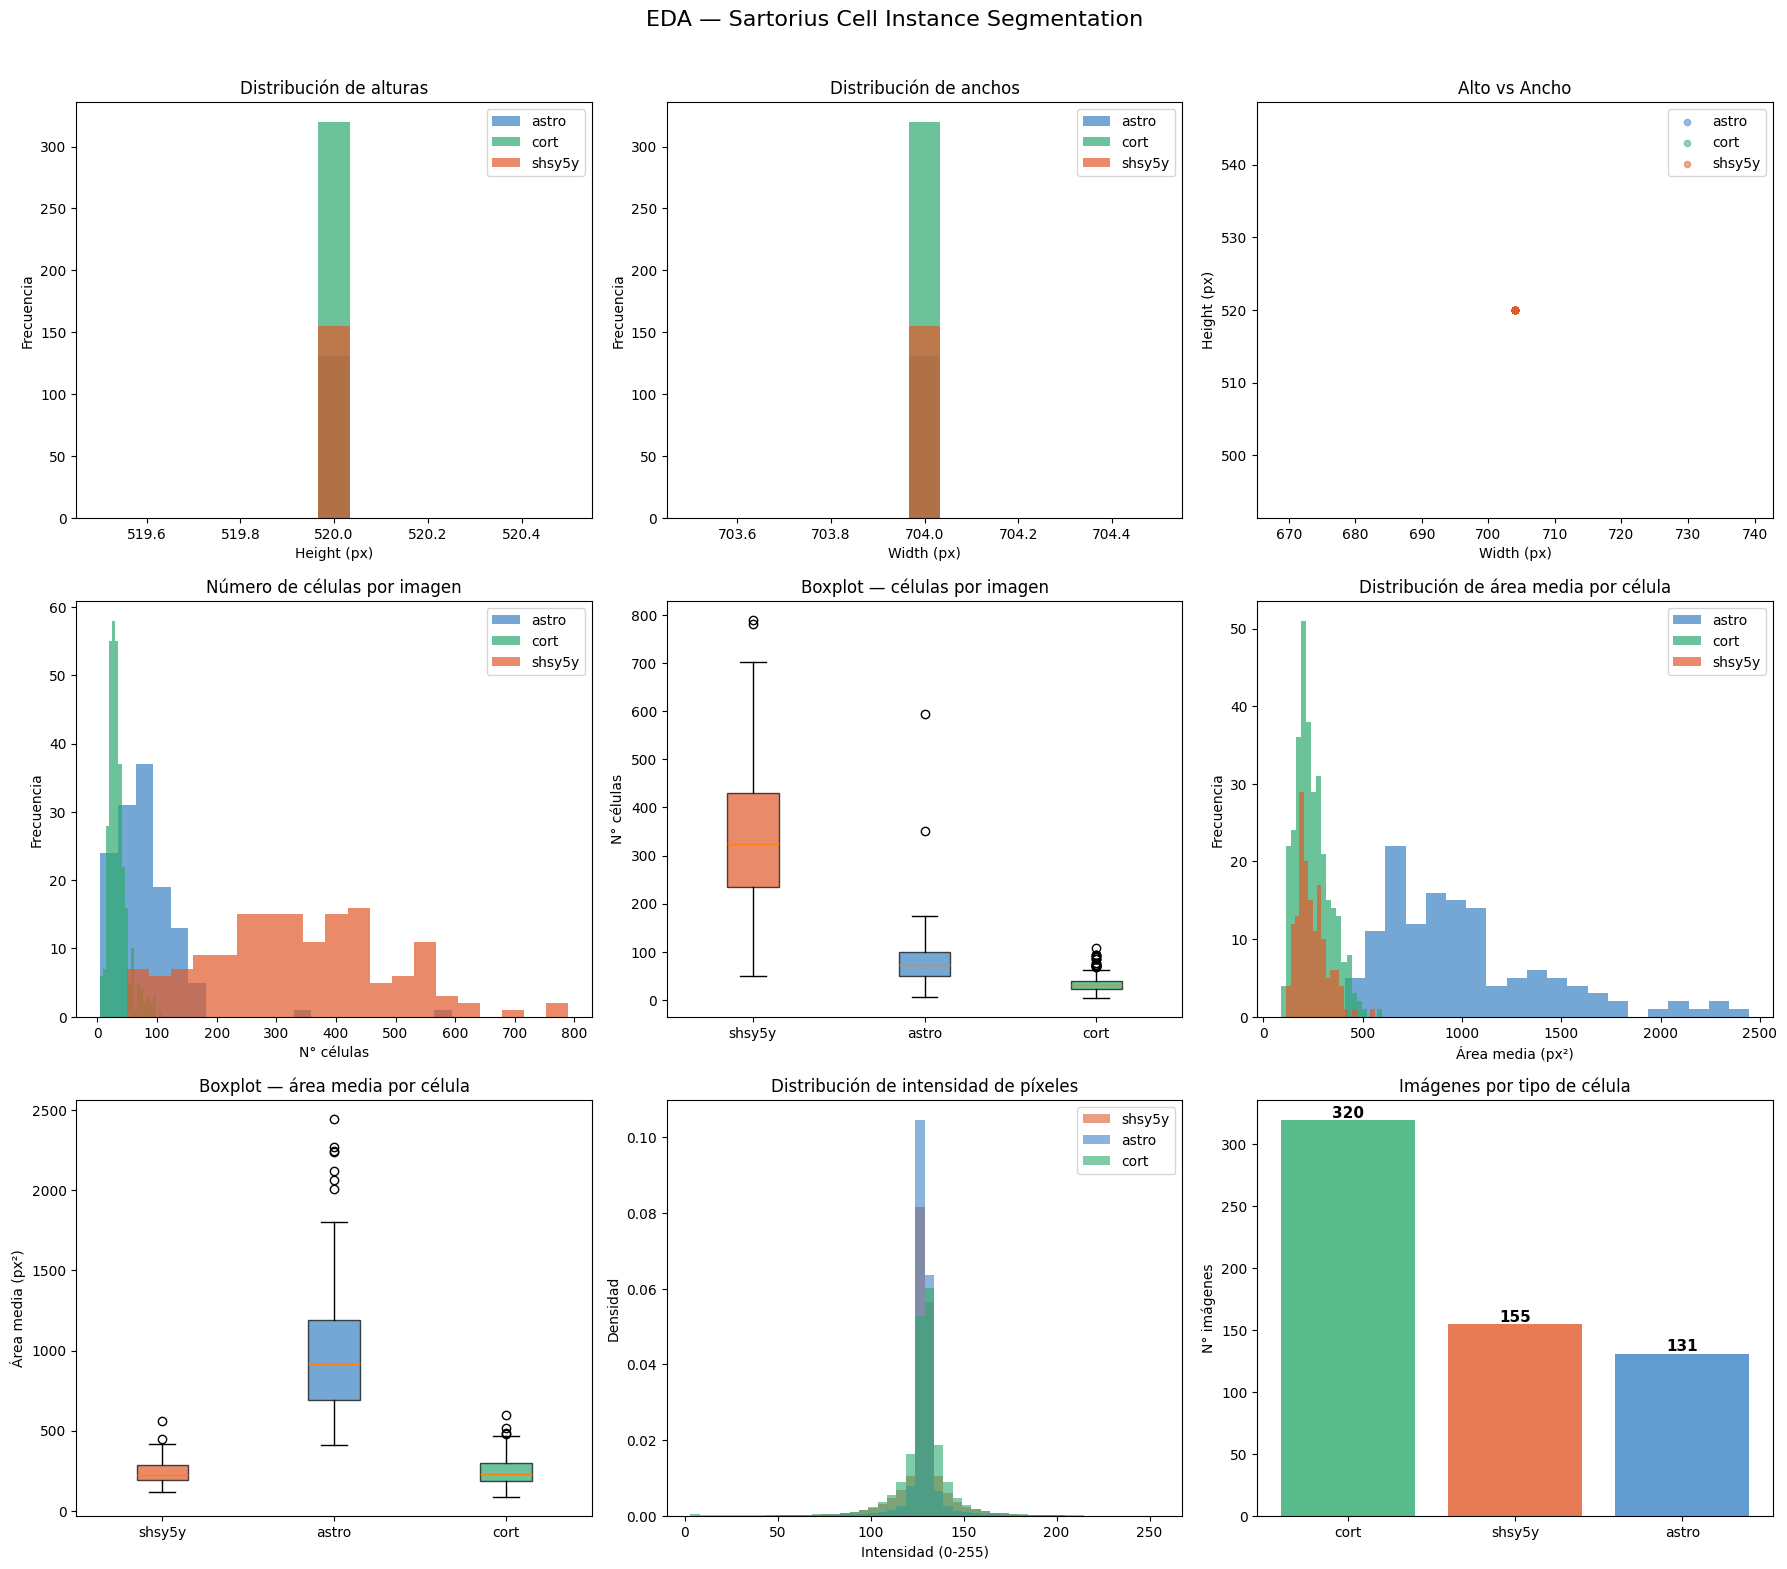

Figura guardada como EDA_completo.png


In [10]:
# ── Celda 6: EDA cuantitativo completo ───────────────────────────
fig = plt.figure(figsize=(18, 20))
fig.suptitle('EDA — Sartorius Cell Instance Segmentation', fontsize=16, y=1.01)

colores = {'shsy5y': '#E05A2B', 'astro': '#3B82C4', 'cort': '#2EAA6E'}

# ── 1. Histograma de alturas ──────────────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
for ct, grp in df_images.groupby('cell_type'):
    ax1.hist(grp['height'], bins=15, alpha=0.7, label=ct, color=colores[ct])
ax1.set_title('Distribución de alturas')
ax1.set_xlabel('Height (px)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# ── 2. Histograma de anchos ───────────────────────────────────────
ax2 = fig.add_subplot(4, 3, 2)
for ct, grp in df_images.groupby('cell_type'):
    ax2.hist(grp['width'], bins=15, alpha=0.7, label=ct, color=colores[ct])
ax2.set_title('Distribución de anchos')
ax2.set_xlabel('Width (px)')
ax2.set_ylabel('Frecuencia')
ax2.legend()

# ── 3. Scatter alto vs ancho ──────────────────────────────────────
ax3 = fig.add_subplot(4, 3, 3)
for ct, grp in df_images.groupby('cell_type'):
    ax3.scatter(grp['width'], grp['height'], alpha=0.5, label=ct, color=colores[ct], s=20)
ax3.set_title('Alto vs Ancho')
ax3.set_xlabel('Width (px)')
ax3.set_ylabel('Height (px)')
ax3.legend()

# ── 4. Histograma número de células por imagen ────────────────────
ax4 = fig.add_subplot(4, 3, 4)
for ct, grp in df_images.groupby('cell_type'):
    ax4.hist(grp['n_celulas'], bins=20, alpha=0.7, label=ct, color=colores[ct])
ax4.set_title('Número de células por imagen')
ax4.set_xlabel('N° células')
ax4.set_ylabel('Frecuencia')
ax4.legend()

# ── 5. Boxplot número de células por tipo ─────────────────────────
ax5 = fig.add_subplot(4, 3, 5)
data_box = [df_images[df_images['cell_type'] == ct]['n_celulas'].values 
            for ct in ['shsy5y', 'astro', 'cort']]
bp = ax5.boxplot(data_box, labels=['shsy5y', 'astro', 'cort'], patch_artist=True)
for patch, ct in zip(bp['boxes'], ['shsy5y', 'astro', 'cort']):
    patch.set_facecolor(colores[ct])
    patch.set_alpha(0.7)
ax5.set_title('Boxplot — células por imagen')
ax5.set_ylabel('N° células')

# ── 6. Histograma de áreas ────────────────────────────────────────
ax6 = fig.add_subplot(4, 3, 6)
for ct, grp in df_images.groupby('cell_type'):
    ax6.hist(grp['area_media'], bins=20, alpha=0.7, label=ct, color=colores[ct])
ax6.set_title('Distribución de área media por célula')
ax6.set_xlabel('Área media (px²)')
ax6.set_ylabel('Frecuencia')
ax6.legend()

# ── 7. Boxplot de áreas ───────────────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
data_area = [df_images[df_images['cell_type'] == ct]['area_media'].values 
             for ct in ['shsy5y', 'astro', 'cort']]
bp2 = ax7.boxplot(data_area, labels=['shsy5y', 'astro', 'cort'], patch_artist=True)
for patch, ct in zip(bp2['boxes'], ['shsy5y', 'astro', 'cort']):
    patch.set_facecolor(colores[ct])
    patch.set_alpha(0.7)
ax7.set_title('Boxplot — área media por célula')
ax7.set_ylabel('Área media (px²)')

# ── 8. Intensidad de píxeles por tipo de célula ───────────────────
ax8 = fig.add_subplot(4, 3, 8)
print("Calculando intensidades")
for ct in ['shsy5y', 'astro', 'cort']:
    sample_ids = df_images[df_images['cell_type'] == ct]['id_imagen'].sample(5, random_state=42)
    intensidades = []
    for img_id in sample_ids:
        img = np.array(Image.open(f"{TRAIN_DIR}\\{img_id}.png").convert('L'))
        intensidades.extend(img.flatten().tolist())
    ax8.hist(intensidades, bins=50, alpha=0.6, label=ct, color=colores[ct], density=True)
ax8.set_title('Distribución de intensidad de píxeles')
ax8.set_xlabel('Intensidad (0-255)')
ax8.set_ylabel('Densidad')
ax8.legend()

# ── 9. Conteo de imágenes por tipo ───────────────────────────────
ax9 = fig.add_subplot(4, 3, 9)
conteos = df_images['cell_type'].value_counts()
bars = ax9.bar(conteos.index, conteos.values, 
               color=[colores[ct] for ct in conteos.index], alpha=0.8)
for bar, val in zip(bars, conteos.values):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(val), ha='center', fontsize=11, fontweight='bold')
ax9.set_title('Imágenes por tipo de célula')
ax9.set_ylabel('N° imágenes')

plt.tight_layout()
plt.savefig('EDA_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como EDA_completo.png")

1. ¿Las imágenes son homogéneas o muy variables?

Todas las imágenes tienen exactamente 520 x 704 px sin excepción. Esto simplifica el preprocesamiento ya que no se requiere manejo de tamaños variables. Sin embargo, son HETEROGÉNEAS en contenido: el número de células por imagen varía drásticamente entre tipos (shsy5y: hasta 790, cort: máximo 108).

2. ¿Existe desbalance en número de células?

Sí hay desbalance en dos niveles:
  • A nivel de imágenes: cort domina con 320 imágenes (52.8%),
    seguido de shsy5y (155, 25.6%) y astro (131, 21.6%).
  • A nivel de instancias por imagen:
    - shsy5y: media 337 células/imagen (muy denso)
    - astro:  media  80 células/imagen (densidad media)
    - cort:   media  34 células/imagen (muy disperso)
  Este desbalance requiere atención en el entrenamiento.

3. ¿Las células son pequeñas o grandes?

Depende del tipo:
  • astro:  las MÁS GRANDES (área media ~900-1000 px²),
            con alta varianza y outliers hasta 2500 px².
  • cort:   tamaño MEDIO (~300 px²), formas redondeadas compactas.
  • shsy5y: las MÁS PEQUEÑAS (~300 px²) pero muy numerosas,
            con formas alargadas e irregulares.

4. ¿Hay ruido o artefactos?

La distribución de intensidad está concentrada en 120-150 (escala de grises media), indicando contraste bajo y uniforme típico de microscopía de contraste de fase. No se observan artefactos evidentes en las 5 imágenes inspeccionadas visualmente.
El bajo contraste entre células y fondo es el principal desafío: las células son casi del mismo tono que el fondo, lo que hace que la segmentación sea no trivial. Las células cort presentan puntos oscuros (núcleos) visibles que pueden facilitar su detección individual.

In [11]:
# ── Estadísticas de respaldo ──────────────────────────────────────
print("Estadísticas de tamaño de imágenes:")
print(df_images[['height','width']].describe())
print("\nEstadísticas de células por imagen por tipo:")
print(df_images.groupby('cell_type')['n_celulas'].describe().round(1))
print("\nEstadísticas de área media por tipo:")
print(df_images.groupby('cell_type')['area_media'].describe().round(1))

Estadísticas de tamaño de imágenes:
       height  width
count   606.0  606.0
mean    520.0  704.0
std       0.0    0.0
min     520.0  704.0
25%     520.0  704.0
50%     520.0  704.0
75%     520.0  704.0
max     520.0  704.0

Estadísticas de células por imagen por tipo:
           count   mean    std   min    25%    50%    75%    max
cell_type                                                       
astro      131.0   80.3   64.1   5.0   50.0   73.0  100.0  594.0
cort       320.0   33.7   16.5   4.0   23.0   30.0   39.0  108.0
shsy5y     155.0  337.3  149.6  49.0  235.5  324.0  429.0  790.0

Estadísticas de área media por tipo:
           count    mean    std    min    25%    50%     75%     max
cell_type                                                           
astro      131.0  1015.1  425.3  410.5  688.6  914.7  1190.4  2446.6
cort       320.0   246.2   86.6   86.8  183.8  228.6   295.8   596.9
shsy5y     155.0   241.8   75.0  113.8  190.8  224.3   286.0   559.3


# Preprocesamiento de Imágenes

Luego del análisis exploratorio, se implementó un pipeline de preprocesamiento para preparar las imágenes para entrenamiento profundo.

El pipeline incluye:

- normalización,
- resize,
- augmentations geométricas,
- augmentations fotométricas.

Estas transformaciones permiten mejorar estabilidad y capacidad de generalización de los modelos.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import os

# ── Rutas ─────────────────────────────────────────────────────────
DATA_DIR  = r"C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\mini3\Bloque1\data\sartorius-cell-instance-segmentation"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
CSV_PATH  = os.path.join(DATA_DIR, "train.csv")

# ── Cargar CSV ────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH)

# ── Función RLE corregida (la que funcionó) ───────────────────────
def rle_decode(rle_string, height, width):
    if pd.isna(rle_string):
        return np.zeros((height, width), dtype=np.uint8)
    nums = list(map(int, rle_string.split()))
    starts = nums[0::2]
    lengths = nums[1::2]
    mask = np.zeros((height, width), dtype=np.uint8)
    for start, length in zip(starts, lengths):
        start -= 1
        for i in range(length):
            pixel = start + i
            row = pixel // width
            col = pixel % width
            if row < height and col < width:
                mask[row, col] = 1
    return mask

def load_image(img_id):
    path = os.path.join(TRAIN_DIR, img_id + '.png')
    return np.array(Image.open(path).convert('RGB'))

def get_combined_mask(img_id, df):
    """Retorna máscara combinada (todas las instancias en una sola matriz)."""
    rows = df[df['id'] == img_id]
    h, w = rows.iloc[0]['height'], rows.iloc[0]['width']
    combined = np.zeros((h, w), dtype=np.uint16)  # ← uint16 aguanta hasta 65535
    for idx, (_, row) in enumerate(rows.iterrows(), start=1):
        mask = rle_decode(row['annotation'], h, w)
        combined[mask == 1] = idx
    return combined

print("Librerías cargadas OK")
print("Albumentations version:", A.__version__)

Librerías cargadas OK
Albumentations version: 2.0.8


# Normalización

Las imágenes fueron normalizadas al rango [0,1] con el objetivo de:

- mejorar estabilidad numérica,
- acelerar convergencia,
- facilitar entrenamiento profundo,
- reducir sensibilidad a variaciones de intensidad.

In [13]:
# ── Celda 2: Normalización y redimensionamiento ───────────────────
IMG_SIZE = 512  # 512x512 como definimos en el plan

def preprocess_image(img_array):
    """Normaliza y redimensiona imagen."""
    img_resized = np.array(Image.fromarray(img_array).resize((IMG_SIZE, IMG_SIZE)))
    img_normalized = img_resized / 255.0
    return img_normalized

def preprocess_mask(mask_array):
    """Redimensiona máscara preservando valores de instancia."""
    mask_resized = np.array(Image.fromarray(mask_array).resize(
        (IMG_SIZE, IMG_SIZE), resample=Image.NEAREST
    ))
    return mask_resized

# ── Probar con una imagen ─────────────────────────────────────────
img_id = df_raw.iloc[0]['id']
img_original = load_image(img_id)
mask_original = get_combined_mask(img_id, df_raw)

img_processed = preprocess_image(img_original)
mask_processed = preprocess_mask(mask_original)

print("── Original ──────────────────────────────")
print(f"  Imagen shape:  {img_original.shape}  | dtype: {img_original.dtype}")
print(f"  Imagen rango:  [{img_original.min()}, {img_original.max()}]")
print(f"  Máscara shape: {mask_original.shape} | instancias: {mask_original.max()}")

print("\n── Procesada ─────────────────────────────")
print(f"  Imagen shape:  {img_processed.shape}  | dtype: {img_processed.dtype}")
print(f"  Imagen rango:  [{img_processed.min():.3f}, {img_processed.max():.3f}]")
print(f"  Máscara shape: {mask_processed.shape} | instancias: {mask_processed.max()}")

── Original ──────────────────────────────
  Imagen shape:  (520, 704, 3)  | dtype: uint8
  Imagen rango:  [3, 255]
  Máscara shape: (520, 704) | instancias: 395

── Procesada ─────────────────────────────
  Imagen shape:  (512, 512, 3)  | dtype: float64
  Imagen rango:  [0.000, 0.949]
  Máscara shape: (512, 512) | instancias: 395


In [14]:
transform_train = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.5),
    A.RandomScale(scale_limit=0.2, p=0.4),       # ← zoom corregido
    A.ElasticTransform(alpha=120, sigma=6, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
])

img_uint8    = img_original.copy()
mask_binaria = (mask_original > 0).astype(np.uint8)

np.random.seed(123)
augmented = transform_train(image=img_uint8, mask=mask_binaria)
img_aug   = augmented['image']
mask_aug  = augmented['mask']

print("Imagen augmentada:", img_aug.shape, "| rango:", img_aug.min(), "-", img_aug.max())
print("Máscara augmentada:", mask_aug.shape, "| valores únicos:", np.unique(mask_aug))

Imagen augmentada: (520, 704, 3) | rango: 3 - 255
Máscara augmentada: (520, 704) | valores únicos: [0 1]


c:\Users\maria\miniconda3\envs\ml_venv\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


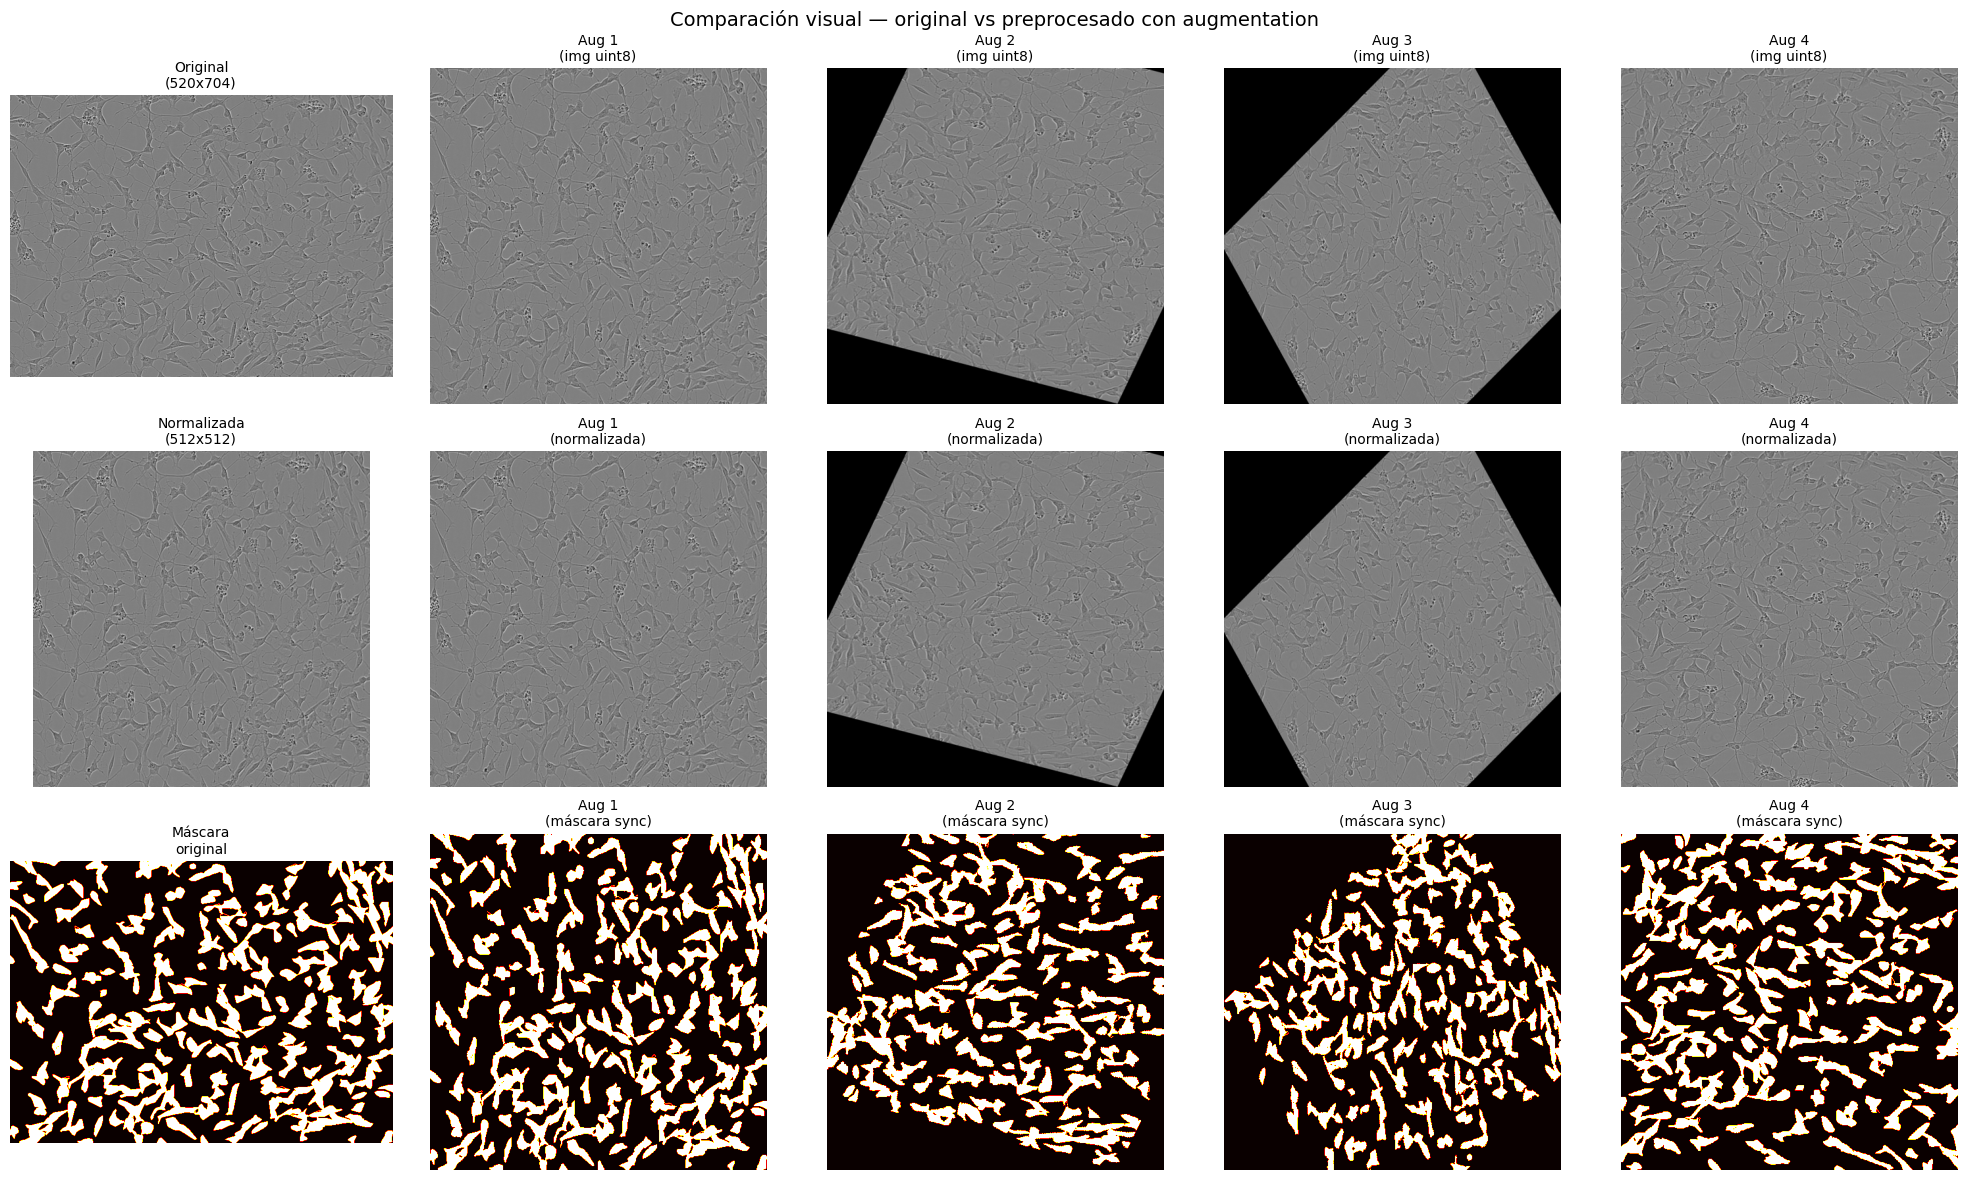

Figura guardada como preprocesamiento_comparacion.png


In [15]:
# ── Celda 4: Comparación visual obligatoria ───────────────────────
# Pipeline completo: augmentation → resize → normalización
def full_pipeline(img, mask, transform, size=512):
    # 1. Augmentation
    augmented  = transform(image=img, mask=mask)
    img_aug    = augmented['image']
    mask_aug   = augmented['mask']
    # 2. Resize
    img_resized  = np.array(Image.fromarray(img_aug).resize((size, size)))
    mask_resized = np.array(Image.fromarray(mask_aug).resize((size, size), resample=Image.NEAREST))
    # 3. Normalización
    img_norm = img_resized / 255.0
    return img_resized, img_norm, mask_resized

img_uint8    = img_original.copy()
mask_binaria = (mask_original > 0).astype(np.uint8)

# Generar 4 versiones augmentadas distintas
seeds = [0, 42, 99, 200]
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Comparación visual — original vs preprocesado con augmentation', fontsize=14)

# Columna 0: original
axes[0, 0].imshow(img_original)
axes[0, 0].set_title('Original\n(520x704)', fontsize=10)
axes[0, 0].axis('off')

axes[1, 0].imshow(preprocess_image(img_original))
axes[1, 0].set_title('Normalizada\n(512x512)', fontsize=10)
axes[1, 0].axis('off')

axes[2, 0].imshow(mask_binaria, cmap='hot')
axes[2, 0].set_title('Máscara\noriginal', fontsize=10)
axes[2, 0].axis('off')

# Columnas 1-4: augmentaciones
for col, seed in enumerate(seeds, start=1):
    np.random.seed(seed)
    img_r, img_n, mask_r = full_pipeline(img_uint8, mask_binaria, transform_train)
    
    axes[0, col].imshow(img_r)
    axes[0, col].set_title(f'Aug {col}\n(img uint8)', fontsize=10)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(img_n)
    axes[1, col].set_title(f'Aug {col}\n(normalizada)', fontsize=10)
    axes[1, col].axis('off')
    
    axes[2, col].imshow(mask_r, cmap='hot')
    axes[2, col].set_title(f'Aug {col}\n(máscara sync)', fontsize=10)
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('preprocesamiento_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como preprocesamiento_comparacion.png")

In [16]:
# ── Celda 5: Dataset PyTorch reutilizable ─────────────────────────
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class SartoriusDataset(Dataset):
    def __init__(self, img_ids, df, train_dir, img_size=512, transform=None, mode='train'):
        self.img_ids   = img_ids
        self.df        = df
        self.train_dir = train_dir
        self.img_size  = img_size
        self.transform = transform
        self.mode      = mode

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        
        # Cargar imagen
        img = np.array(Image.open(
            os.path.join(self.train_dir, img_id + '.png')).convert('RGB'))
        
        # Cargar máscara combinada
        rows = self.df[self.df['id'] == img_id]
        h, w = rows.iloc[0]['height'], rows.iloc[0]['width']
        mask = np.zeros((h, w), dtype=np.uint16)
        for i, (_, row) in enumerate(rows.iterrows(), start=1):
            m = rle_decode(row['annotation'], h, w)
            mask[m == 1] = i
        mask_binary = (mask > 0).astype(np.uint8)

        # Augmentation sincronizada
        if self.transform:
            aug     = self.transform(image=img, mask=mask_binary)
            img     = aug['image']
            mask_binary = aug['mask']

        # Resize + normalización
        img         = np.array(Image.fromarray(img).resize((self.img_size, self.img_size)))
        mask_binary = np.array(Image.fromarray(mask_binary).resize(
                          (self.img_size, self.img_size), resample=Image.NEAREST))
        img = img / 255.0

        # A tensor
        img_tensor  = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # C,H,W
        mask_tensor = torch.tensor(mask_binary, dtype=torch.long)

        return img_tensor, mask_tensor

# ── Split 70/15/15 ────────────────────────────────────────────────
all_ids = df_raw['id'].unique()
train_ids, temp_ids = train_test_split(all_ids, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids, test_size=0.50, random_state=42)

print(f"Train:      {len(train_ids)} imágenes ({len(train_ids)/len(all_ids)*100:.1f}%)")
print(f"Validation: {len(val_ids)}  imágenes ({len(val_ids)/len(all_ids)*100:.1f}%)")
print(f"Test:       {len(test_ids)}  imágenes ({len(test_ids)/len(all_ids)*100:.1f}%)")

# ── Verificar que el Dataset funciona ─────────────────────────────
ds_train = SartoriusDataset(train_ids, df_raw, TRAIN_DIR, transform=transform_train)
ds_val   = SartoriusDataset(val_ids,   df_raw, TRAIN_DIR, transform=None)
ds_test  = SartoriusDataset(test_ids,  df_raw, TRAIN_DIR, transform=None)

img_t, mask_t = ds_train[0]
print(f"\nSample tensor — imagen: {img_t.shape} | máscara: {mask_t.shape}")
print(f"Imagen rango: [{img_t.min():.3f}, {img_t.max():.3f}]")
print(f"Máscara valores únicos: {mask_t.unique()}")

Train:      424 imágenes (70.0%)
Validation: 91  imágenes (15.0%)
Test:       91  imágenes (15.0%)

Sample tensor — imagen: torch.Size([3, 512, 512]) | máscara: torch.Size([512, 512])
Imagen rango: [0.000, 0.871]
Máscara valores únicos: tensor([0, 1])


# Conclusiones del EDA y Preprocesamiento

El análisis exploratorio permitió identificar:

- alta variabilidad morfológica celular,
- diferencias importantes entre tipos celulares,
- desbalance en densidad celular,
- variaciones de intensidad y textura,
- necesidad de augmentations robustas.

El pipeline de preprocesamiento permitió:

- homogenizar entradas,
- mejorar estabilidad numérica,
- incrementar capacidad de generalización,
- preparar adecuadamente los datos para entrenamiento profundo.

Estos hallazgos justifican el uso de arquitecturas avanzadas de segmentación celular.